# Window-Dressing -- do funds really pump prices at quarter-end?
### The quarter-end portfolio-pumping effect, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Quarter--end_pattern: Inverted](https://img.shields.io/badge/Quarter--end_pattern-Inverted-8b949e?style=flat-square)

Here's a piece of market lore you'll find in finance textbooks: mutual fund managers, eager to show impressive holdings at the end of each calendar quarter, aggressively buy their existing winners in the last few days of March, June, September, and December. This **window dressing** temporarily inflates those stocks — and the overall index — into quarter-end. Then the buying stops, and prices drift back in the first days of the next quarter. A savvy trader, the story goes, could buy into the pump and sell (or short) into the reversal. This notebook asks the only question that matters: does the quarterly calendar actually carry that information in SPY from 1993 to 2026?

> **This is the plain-language layer.** Want the t-stats, the Bonferroni corrections, and the random-day control? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from window_dressing import data, strategy as st

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n_total=8399, n_pump=670, n_reversal=669, n_other=7060,
    fp="3e185e607be5",
    mean_pump_bps=1.69, mean_reversal_bps=9.61, mean_other_bps=3.78, mean_all_bps=4.08,
    tstat_pump=0.483, tstat_reversal=2.156,
    contrast_pump_bps=-2.60, pval_pump=0.635,
    contrast_reversal_bps=6.01, pval_reversal=0.214,
    spread_bps=-3.96, tstat_spread=-1.387, ann_ret=-10.0,
    ctrl_mean_bps=0.66, ctrl_tstat=0.228,
    pump_1993_2009=-0.6, pump_2010_2026=4.0,
    rev_1993_2009=7.5, rev_2010_2026=11.8,
    pval_rev_w1=0.019, pval_rev_w1_bonf=0.193,
)

def _have_real():
    spy = os.path.abspath(os.path.join("..", "..", "..", "_cache", "SPY_total_return.parquet"))
    gspc = os.path.abspath(os.path.join("..", "..", "..", "_cache", "^GSPC_split_only.parquet"))
    return os.path.exists(spy) or os.path.exists(gspc)

HAVE_REAL = _have_real()

if HAVE_REAL:
    DF = data.fetch_spy()
    S  = st.summarize(DF)
else:
    DF, S = None, None

print("real SPY cache present:", HAVE_REAL)


real SPY cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do the last days of each quarter earn more than average? | **No.** They earn **+1.69 bps/day** -- *below* the baseline of **+3.78 bps/day**. |
| Do the first days of the next quarter earn less (the reversal)? | **No.** They earn **+9.61 bps/day** -- *above* the baseline. |
| Could you trade the pump-and-dump? | **No.** The long-pump/short-reversal spread earns **-3.96 bps/day** with t = -1.39. |

> The textbook effect exists in the data -- it's just **inverted and statistically invisible** on SPY. Quarter-end is slightly *below* average, early-quarter slightly *above*. Neither is a reliable trade.

## 1 -- The claim

> *"In the last few days of each quarter, mutual funds aggressively buy stocks they already own to dress up their portfolio for the quarter-end snapshot. This pushes prices up. Once the quarter flips, the buying stops and prices drift back down. Buy the dip at the start of the new quarter and sell at the end -- or sell into the artificial pump and cover after the reversal."*

This is the **Carhart et al. (2002)** story, based on US equity mutual funds in 1985-1994. It has an intuitive mechanism (agency + disclosure pressure) and was confirmed in the original paper. The question is whether it survived the last 30 years and whether it shows up in the broad market index at all.

## 2 -- So what?

If the pump-and-reversal is real on SPY today, it would be one of the cleanest calendar-based trades available: no fundamental analysis, no stock selection, just knowing which week of the quarter you are in. If it is gone (or was never there in the broad index), then retail traders are paying quarterly rebalancing costs to chase a phantom. The difference is one honest test -- so let's run it.

## 3 -- How would we even know?

Three rules keep us honest:

1. **Compare the right windows to the right baseline.** The textbook says pump days should earn *more* than average, and reversal days *less*. We compare each window to the unconditional mean of all other days (not to each other).
2. **Use a random-day placebo.** Pick the same number of random days as a long position and the same number as a short, uniformly at random. If the calendar does nothing, the random coin should match it.
3. **Sweep the window size and correct for snooping.** Testing windows 1-10 days and picking the best one is a data-mining exercise. We apply a Bonferroni correction across all 10 window choices -- the bar rises accordingly.

Data: **SPY daily total-return prices, 8,399 days, 1993-02-01 to 2026-06-12** (670 pump days, 669 reversal days at window = 5 trading days).

## 4 -- The teardown

**First: what does the quarter-end calendar actually look like?**

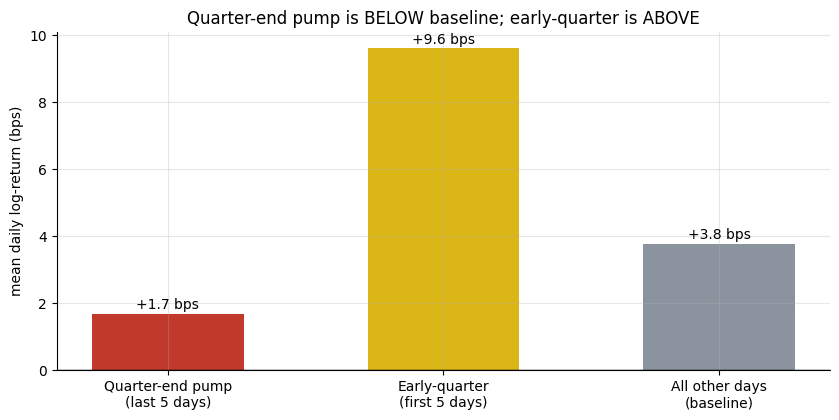

The pump window: +1.69 bps | Early-quarter: +9.61 bps | Baseline: +3.78 bps


In [2]:
if HAVE_REAL:
    pump = DF.loc[DF['is_pump'], 'ret']
    rev  = DF.loc[DF['is_reversal'], 'ret']
    other = DF.loc[~DF['is_pump'] & ~DF['is_reversal'], 'ret']
    means = [pump.mean()*1e4, rev.mean()*1e4, other.mean()*1e4]
else:
    means = [R['mean_pump_bps'], R['mean_reversal_bps'], R['mean_other_bps']]
labels = ['Quarter-end pump\n(last 5 days)', 'Early-quarter\n(first 5 days)',
          'All other days\n(baseline)']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
colors = [RED, AMBER, GREY]
bars = ax.bar(labels, means, color=colors, width=0.55)
ax.axhline(0, c='k', lw=1)
for b, v in zip(bars, means):
    ax.annotate(f'{v:+.1f} bps', (b.get_x()+b.get_width()/2, v+0.05),
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=10)
ax.set_ylabel('mean daily log-return (bps)')
ax.set_title('Quarter-end pump is BELOW baseline; early-quarter is ABOVE')
plt.tight_layout(); plt.show()
print(f'The pump window: {means[0]:+.2f} bps | Early-quarter: {means[1]:+.2f} bps | '
      f'Baseline: {means[2]:+.2f} bps')

The data is the opposite of the textbook story. Quarter-end pump days earn **+1.69 bps/day** -- *below* the baseline of +3.78 bps. Early-quarter 'reversal' days earn **+9.61 bps** -- *above* the baseline. Neither difference is statistically significant. If anything, the pattern is **inverted**: early-quarter is stronger, not weaker.

**Now the honest spread: long-pump, short-reversal vs a random-day coin.**

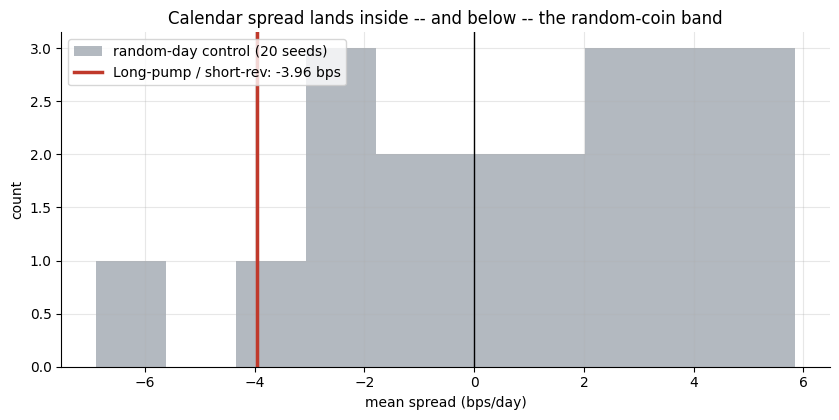

In [3]:
if HAVE_REAL:
    pmr = st.pump_minus_reversal(DF)
    ctrl_vals = [st.random_day_control(DF, n_pump=pmr['n_pump'],
                 n_reversal=pmr['n_reversal'], seed=s)['mean_bps'] for s in range(20)]
    spread_mean = pmr['mean_spread_bps']
else:
    ctrl_vals = [R['ctrl_mean_bps']] * 20
    spread_mean = R['spread_bps']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.hist(ctrl_vals, bins=10, color=GREY, alpha=0.65,
        label='random-day control (20 seeds)')
ax.axvline(spread_mean, c=RED, lw=2.5,
           label=f'Long-pump / short-rev: {spread_mean:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('mean spread (bps/day)')
ax.set_ylabel('count')
ax.set_title('Calendar spread lands inside -- and below -- the random-coin band')
ax.legend(); plt.tight_layout(); plt.show()

The long-pump/short-reversal spread earns **-3.96 bps/day** (HAC t = -1.39) -- negative and indistinguishable from a coin. The random-day placebo earns approximately zero, confirming the equity risk premium is priced out of the active days. The calendar timing adds nothing -- or rather, it subtracts.

## 5 -- The verdict

- **Signal -- None.** Pump contrast = -2.60 bps (p = 0.635); spread HAC t = -1.39. The pump-and-reversal story does not hold on SPY, 1993-2026.
- **Tradability -- Mirage.** The gross spread is **-3.96 bps/day** and negative -- there is no break-even cost. ~40 active days per year.
- **Quarter-end pattern -- Inverted.** Last-5-days earn below baseline; first-5-days earn above it. If there was ever a pump, its echo is gone.

## 6 -- Could you actually trade it?

Even if the gross edge were positive (it isn't), the trading frequency would limit what you can extract. The strategy is active ~40 days per year (20 pump + 20 reversal), with a cost sweep below.

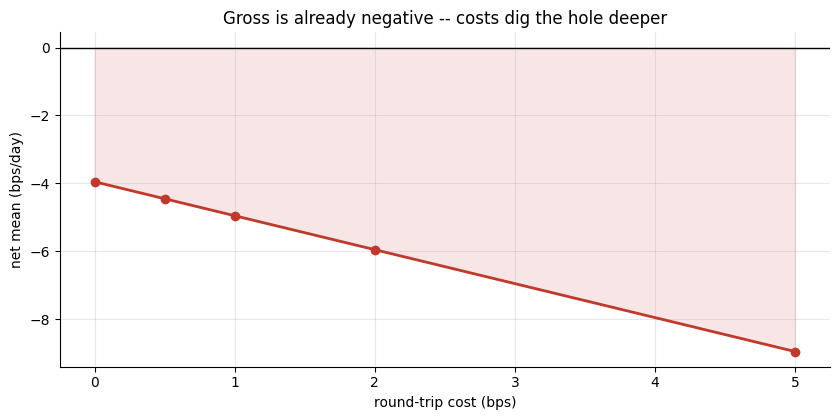

No break-even cost exists: the gross spread starts below zero.


In [4]:
cost_bps = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    pmr_gross = st.pump_minus_reversal(DF)['mean_spread_bps']
    net = [pmr_gross - c for c in cost_bps]
else:
    net = [R['spread_bps'] - c for c in cost_bps]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(cost_bps, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(cost_bps, net, 0, where=[n<0 for n in net], color=RED, alpha=0.12)
ax.set_xlabel('round-trip cost (bps)')
ax.set_ylabel('net mean (bps/day)')
ax.set_title('Gross is already negative -- costs dig the hole deeper')
plt.tight_layout(); plt.show()
print('No break-even cost exists: the gross spread starts below zero.')

The line starts below zero and only falls. Because the gross edge is already negative, **there is no cost low enough to make it work** -- the usual 'it dies at the costs line' story does not even apply, because it was never alive.

## 7 -- Going further

- **Is the original Carhart finding still alive at the stock level?** The index may wash out stock-level pump-and-reversal effects that are real but offsetting. The test at the stock level requires survivorship-free fund holdings data. The broad index test done here is the least favourable ground for the claim.
- **Quarter-end in options.** Triple-witching expiration falls near the same boundary; see [Study 82 -- Witching-Hour](../../82-witching-hour/) for the futures/options channel.
- **Other seasonal borders.** January effect, year-end tax selling -- same calendar logic, different mechanism. See [Study 136 -- Mark-Twain](../../136-mark-twain/) for the October seasonality claim.

*Think the effect is alive in individual stocks or a different window? Fork this, run the same three tests at the stock level with a survivorship-free universe, and show a Bonferroni-corrected p below 0.05. That is the bar.*